In [1]:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

In [2]:
tasas = pd.read_csv("df_tasass.csv")

In [3]:
tasas

,año,nom_mun,tasa_mortalidad,tasa_mortalidad_masc,tasa_mortalidad_fem,pobreza_porcentaje,tasa_edad_0_14,tasa_edad_15_24,tasa_edad_25_59,tasa_edad_60mas,tasa_esc_sin_preescolar,tasa_esc_primaria,tasa_esc_secundaria,tasa_esc_prep_superior
0,2015,Total de la entidad Ciudad de México,84.314156,90.291259,78.834138,27.20869,0.061864,0.844544,37.378289,233.602069,408.039046,375.474092,73.519740,40.803119
1,2015,Azcapotzalco,102.017201,117.704562,87.909722,19.50000,0.000000,0.000000,42.311358,498.764190,467.679973,481.587578,97.468681,50.842320
2,2015,Coyoacán,81.142539,84.594223,78.069748,19.80000,0.000000,0.000000,25.729776,389.974750,473.525613,419.133442,93.637085,40.112802
3,2015,Cuajimalpa de Morelos,47.515814,50.831985,44.489460,30.10000,2.399232,0.000000,17.951116,379.848061,413.323608,204.976838,39.096098,17.247114
4,2015,Gustavo A. Madero,104.021662,109.416901,99.018313,28.40000,0.000000,1.068256,44.642710,542.706143,400.335519,449.137903,86.594168,47.785855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,2020,Xochimilco,146.999625,171.731987,123.497085,48.20000,0.000000,1.390144,70.909736,808.368997,628.861430,641.493489,135.747098,71.084893
98,2020,Benito Juárez,69.100064,78.665750,60.767480,7.90000,0.000000,0.000000,15.112529,299.963363,510.915002,557.011796,184.195985,46.756496
99,2020,Cuauhtémoc,141.971554,159.033688,126.345492,20.90000,0.000000,2.853596,54.279903,651.323434,691.130492,704.892394,191.450204,81.540032
100,2020,Miguel Hidalgo,102.781866,114.085754,92.692794,13.50000,0.000000,0.000000,38.615180,476.719495,874.635569,629.262462,149.488748,55.803352


In [4]:
print(tasas.columns.tolist())

['año', 'nom_mun', 'tasa_mortalidad', 'tasa_mortalidad_masc', 'tasa_mortalidad_fem', 'pobreza_porcentaje', 'tasa_edad_0_14', 'tasa_edad_15_24', 'tasa_edad_25_59', 'tasa_edad_60mas', 'tasa_esc_sin_preescolar', 'tasa_esc_primaria', 'tasa_esc_secundaria', 'tasa_esc_prep_superior']


In [5]:
tasas = tasas[tasas['nom_mun'] != 'Total de la entidad Ciudad de México']#quitamos a la cdmx para que no haya sesgos
tasas.head(40)

,año,nom_mun,tasa_mortalidad,tasa_mortalidad_masc,tasa_mortalidad_fem,pobreza_porcentaje,tasa_edad_0_14,tasa_edad_15_24,tasa_edad_25_59,tasa_edad_60mas,tasa_esc_sin_preescolar,tasa_esc_primaria,tasa_esc_secundaria,tasa_esc_prep_superior
1,2015,Azcapotzalco,102.017201,117.704562,87.909722,19.50,0.000000,0.000000,42.311358,498.764190,467.679973,481.587578,97.468681,50.842320
2,2015,Coyoacán,81.142539,84.594223,78.069748,19.80,0.000000,0.000000,25.729776,389.974750,473.525613,419.133442,93.637085,40.112802
3,2015,Cuajimalpa de Morelos,47.515814,50.831985,44.489460,30.10,2.399232,0.000000,17.951116,379.848061,413.323608,204.976838,39.096098,17.247114
4,2015,Gustavo A. Madero,104.021662,109.416901,99.018313,28.40,0.000000,1.068256,44.642710,542.706143,400.335519,449.137903,86.594168,47.785855
5,2015,Iztacalco,113.558592,119.502996,108.177024,17.10,0.000000,0.000000,48.987748,572.890870,621.414914,520.403630,102.176936,50.674923
6,2015,Iztapalapa,81.615393,86.506755,77.020159,35.00,0.000000,0.645790,42.252587,510.991220,338.706911,327.953676,52.898324,40.010095
7,2015,La Magdalena Contreras,68.213385,72.171149,64.585237,32.60,0.000000,0.000000,32.068755,404.157044,304.971028,285.156836,52.649026,26.015696
8,2015,Milpa Alta,96.022142,99.592968,92.602831,49.20,0.000000,0.000000,51.904611,764.759865,526.870390,409.696142,51.522785,33.813158
9,2015,Álvaro Obregón,74.150233,76.656747,71.875594,27.90,0.000000,2.509977,33.032599,417.229595,440.583307,326.413927,59.174448,28.237801
10,2015,Tláhuac,73.082126,72.796935,73.351275,39.20,0.000000,1.509707,38.026775,549.540682,407.221393,334.918338,48.581653,31.297972


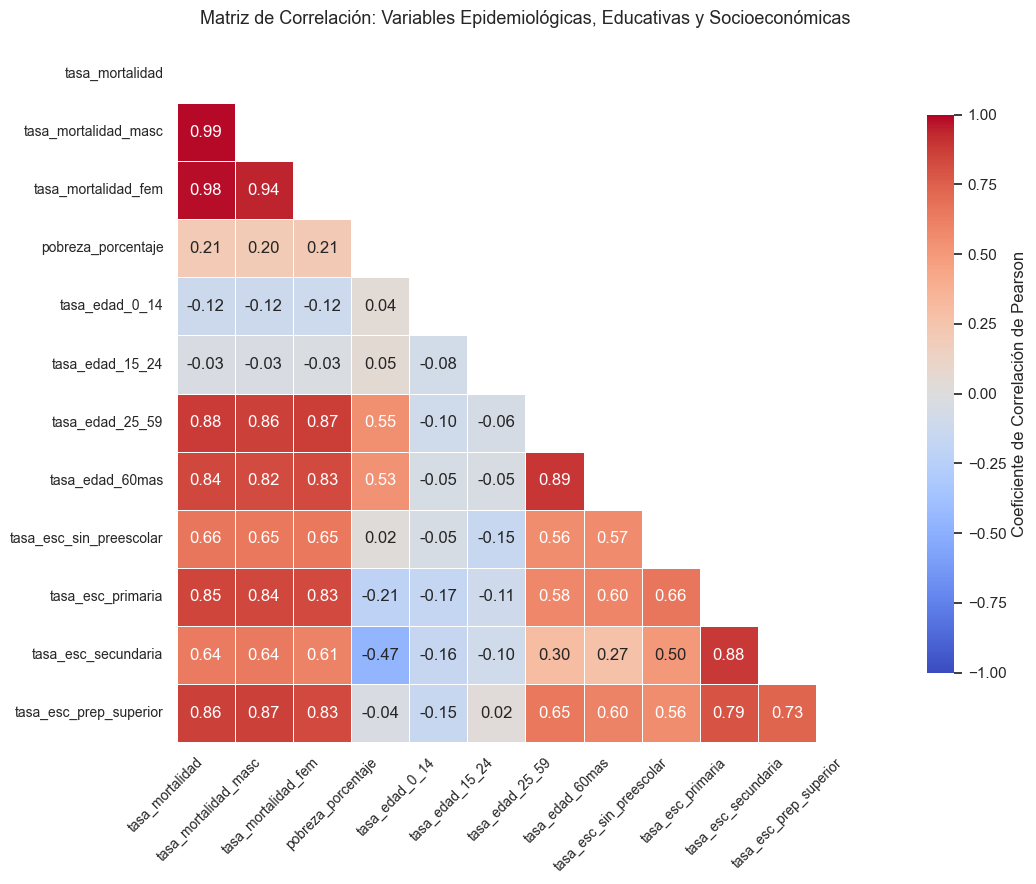

In [6]:

# 1. Seleccionar únicamente las columnas numéricas relevantes para la correlación
columnas_variables = [
    'tasa_mortalidad',
    'tasa_mortalidad_masc',
    'tasa_mortalidad_fem',
    'pobreza_porcentaje',
    'tasa_edad_0_14',
    'tasa_edad_15_24',
    'tasa_edad_25_59',
    'tasa_edad_60mas',
    'tasa_esc_sin_preescolar',
    'tasa_esc_primaria',
    'tasa_esc_secundaria',
    'tasa_esc_prep_superior',
]

# 2. Calcular la matriz de correlación de Pearson
matriz_corr = tasas[columnas_variables].corr()

# 3. Configurar la figura
plt.figure(figsize=(12, 9))
sns.set_theme(style='white')

# Crear una máscara para ocultar la mitad superior repetida (opcional, para mayor limpieza)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# 4. Dibujar el Mapa de Calor
sns.heatmap(
    matriz_corr,
    mask=mask,
    annot=True,  # Muestra los valores numéricos dentro de las celdas
    fmt='.2f',  # Formato con 2 decimales
    cmap='coolwarm',  # Paleta: rojo para positiva, azul para negativa
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlación de Pearson'},
)

# 5. Personalización de etiquetas
plt.title(
    'Matriz de Correlación: Variables Epidemiológicas, Educativas y Socioeconómicas',
    fontsize=13,
    pad=15,
)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.savefig('modelo/corrrelacionTASAS.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [7]:
print(matriz_corr)

                         tasa_mortalidad  tasa_mortalidad_masc  \
tasa_mortalidad                 1.000000              0.987520   
tasa_mortalidad_masc            0.987520              1.000000   
tasa_mortalidad_fem             0.980829              0.937935   
pobreza_porcentaje              0.209517              0.196065   
tasa_edad_0_14                 -0.118592             -0.118297   
tasa_edad_15_24                -0.033146             -0.034212   
tasa_edad_25_59                 0.880580              0.859886   
tasa_edad_60mas                 0.840361              0.821013   
tasa_esc_sin_preescolar         0.661891              0.652180   
tasa_esc_primaria               0.847487              0.838497   
tasa_esc_secundaria             0.635413              0.642058   
tasa_esc_prep_superior          0.864640              0.866624   

                         tasa_mortalidad_fem  pobreza_porcentaje  \
tasa_mortalidad                     0.980829            0.209517   
tasa_

## Propuesta PCA

In [8]:


# 1. Seleccionar únicamente las variables numéricas representativas
col_features = [
    'tasa_mortalidad',  # Representante general (se omiten masc/fem por r > 0.98)
    'pobreza_porcentaje',
    'tasa_edad_25_59',  # Se omiten 0-14 y 15-24 por r ~ 0
    'tasa_edad_60mas',
    'tasa_esc_sin_preescolar',
    'tasa_esc_primaria',
    'tasa_esc_secundaria',
    'tasa_esc_prep_superior',
]

X = tasas[col_features]

# 2. Estandarizar los datos (Media = 0, Varianza = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar PCA (inicialmente sin limitar componentes para analizar el codo)
pca_full = PCA()
pca_full.fit(X_scaled)

# Calcular varianza explicada acumulada
var_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

print('--- Varianza Explicada Acumulada ---')
for i, var in enumerate(var_acumulada):
    print(f'Componente {i+1}: {var*100:.2f}%')

# 4. Ajustar PCA con el número óptimo de componentes (ej. 3 componentes)
n_components = 2  # Ajusta este número según los resultados del print anterior inicio3
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# 5. Crear el nuevo DataFrame con los Componentes Principales
col_pca = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=col_pca)

# Reintegrar las columnas identificadoras
df_pca['año'] = tasas['año'].values
df_pca['nom_mun'] = tasas['nom_mun'].values

# Reordenar columnas para que año y nom_mun queden al inicio
df_pca = df_pca[['año', 'nom_mun'] + col_pca]

print('\n--- Vista previa del DataFrame para Clustering ---')
print(df_pca.head())

--- Varianza Explicada Acumulada ---
Componente 1: 62.83%
Componente 2: 87.27%
Componente 3: 93.55%
Componente 4: 96.27%
Componente 5: 97.99%
Componente 6: 99.23%
Componente 7: 99.74%
Componente 8: 100.00%

--- Vista previa del DataFrame para Clustering ---
    año                nom_mun       PC1       PC2
0  2015           Azcapotzalco  0.489633  0.671151
1  2015               Coyoacán -0.975123  1.037013
2  2015  Cuajimalpa de Morelos -3.488743 -0.616236
3  2015      Gustavo A. Madero  0.306517 -0.231810
4  2015              Iztacalco  1.498629  0.667962


In [9]:
# Crear un DataFrame con las cargas (loadings) de los componentes
df_loadings = pd.DataFrame(
    pca.components_.T, index=col_features, columns=col_pca
)

print('\n--- Cargas de cada variable por Componente ---')
print(df_loadings)


--- Cargas de cada variable por Componente ---
                              PC1       PC2
tasa_mortalidad          0.436460 -0.058489
pobreza_porcentaje       0.063980 -0.682668
tasa_edad_25_59          0.377406 -0.335322
tasa_edad_60mas          0.369817 -0.337425
tasa_esc_sin_preescolar  0.336248  0.052424
tasa_esc_primaria        0.399509  0.260787
tasa_esc_secundaria      0.315273  0.464492
tasa_esc_prep_superior   0.392609  0.133179


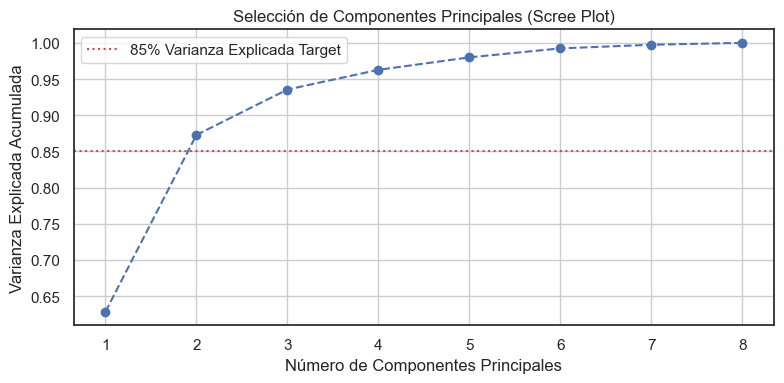

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(var_acumulada) + 1),
    var_acumulada,
    marker='o',
    linestyle='--',
    color='b',
)
plt.axhline(
    y=0.85, color='r', linestyle=':', label='85% Varianza Explicada Target'
)
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Selección de Componentes Principales (Scree Plot)')
plt.grid(True)
plt.legend()
plt.savefig('modelo/numeroPCA.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## K-MEANS

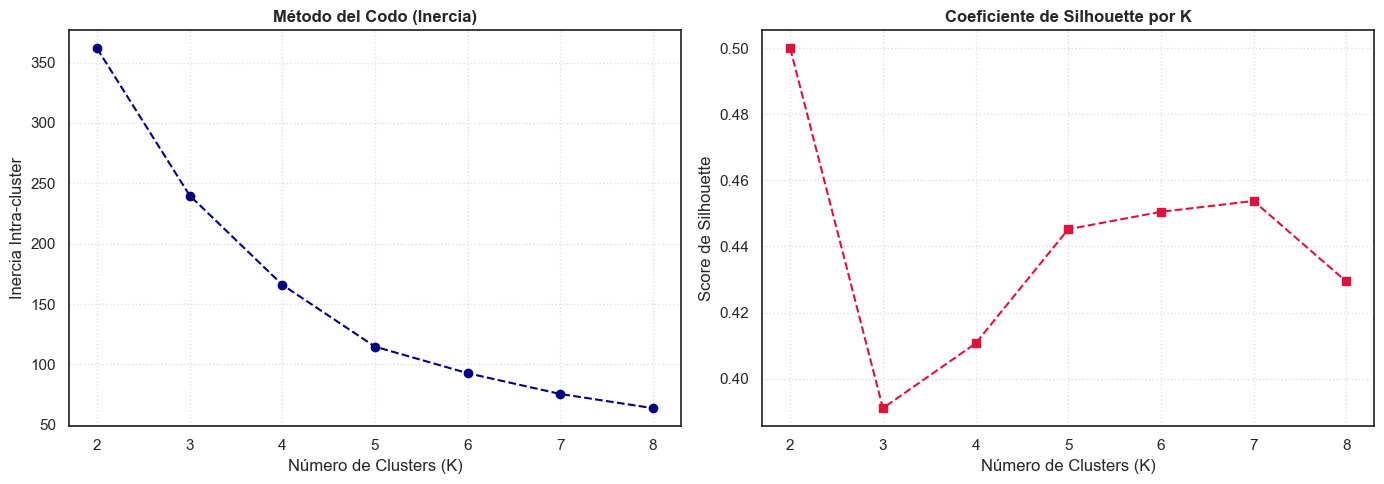

--- Evaluación de Silhouette ---
K = 2: Silhouette Score = 0.4999
K = 3: Silhouette Score = 0.3911
K = 4: Silhouette Score = 0.4106
K = 5: Silhouette Score = 0.4452
K = 6: Silhouette Score = 0.4505
K = 7: Silhouette Score = 0.4538
K = 8: Silhouette Score = 0.4294


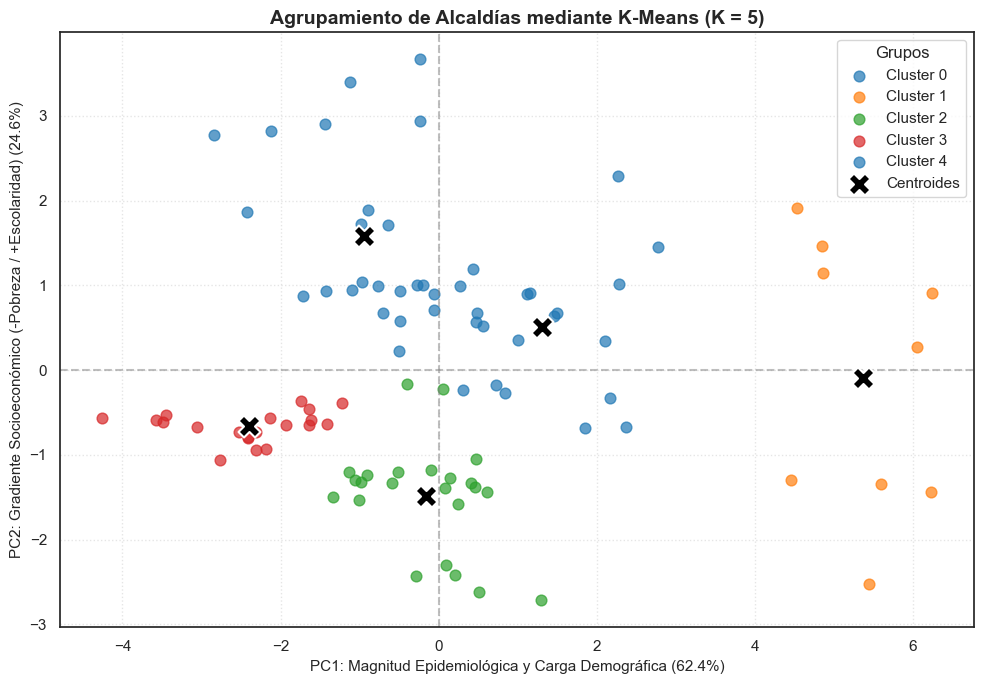

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Asumimos que df_pca contiene las columnas ['nom_mun', 'año', 'PC1', 'PC2']
X_pca_2d = df_pca[['PC1', 'PC2']].values

# -------------------------------------------------------------------------
# 1. Evaluación del K Óptimo (Codo y Coeficiente de Silhouette)
# -------------------------------------------------------------------------
k_range = range(2, 9)
inercias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_2d)

    inercias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_pca_2d, kmeans.labels_)
    silhouettes.append(sil_score)

# Graficar Método del Codo y Silhouette side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Método del Codo (Inercia)
ax[0].plot(k_range, inercias, marker='o', color='navy', linestyle='--')
ax[0].set_title('Método del Codo (Inercia)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Número de Clusters (K)')
ax[0].set_ylabel('Inercia Intra-cluster')
ax[0].grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: Coeficiente de Silhouette
ax[1].plot(k_range, silhouettes, marker='s', color='crimson', linestyle='--')
ax[1].set_title(
    'Coeficiente de Silhouette por K', fontsize=12, fontweight='bold'
)
ax[1].set_xlabel('Número de Clusters (K)')
ax[1].set_ylabel('Score de Silhouette')
ax[1].grid(True, linestyle=':', alpha=0.6)
plt.savefig('modelo/codoKMEANS.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# Imprimir las puntuaciones numéricas
print('--- Evaluación de Silhouette ---')
for k, score in zip(k_range, silhouettes):
    print(f'K = {k}: Silhouette Score = {score:.4f}')

# -------------------------------------------------------------------------
# 2. Ajuste del Modelo Final K-Means
# -------------------------------------------------------------------------
# Seleccionamos K óptimo (habitualmente K=3 o K=4 según la inflexión de Silhouette)
k_optimo = 5

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_pca['cluster'] = kmeans_final.fit_predict(X_pca_2d)
centroides = kmeans_final.cluster_centers_

# -------------------------------------------------------------------------
# 3. Visualización del Plano Cartesiano de Clusters (PC1 vs PC2)
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 7))

# Graficar los puntos asignados a cada cluster
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for cluster_id in range(k_optimo):
    sub_df = df_pca[df_pca['cluster'] == cluster_id]
    plt.scatter(
        sub_df['PC1'],
        sub_df['PC2'],
        s=60,
        alpha=0.7,
        color=colors[cluster_id % len(colors)],
        label=f'Cluster {cluster_id}',
    )

# Graficar los centroides
plt.scatter(
    centroides[:, 0],
    centroides[:, 1],
    s=250,
    c='black',
    marker='X',
    edgecolor='white',
    linewidth=1.5,
    label='Centroides',
    zorder=10,
)

# Configuración del gráfico
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title(
    f'Agrupamiento de Alcaldías mediante K-Means (K = {k_optimo})',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel(
    'PC1: Magnitud Epidemiológica y Carga Demográfica (62.4%)', fontsize=11
)
plt.ylabel(
    'PC2: Gradiente Socioeconómico (-Pobreza / +Escolaridad) (24.6%)',
    fontsize=11,
)
plt.legend(title='Grupos', loc='best')
plt.grid(True, linestyle=':', alpha=0.5)
plt.savefig('modelo/agrupamientoKMEANS.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [12]:
# 1. Asignar el K=5 al DataFrame original con las variables sin escalar
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
tasas_alcaldias = tasas.copy()
tasas_alcaldias['cluster_k5'] = kmeans_5.fit_predict(X_pca_2d)

# 2. Calcular la media de las variables originales por cada cluster
perfil_clusters = tasas_alcaldias.groupby('cluster_k5')[col_features].mean()

# 3. Formatear para facilitar la lectura
print('--- Perfil Promedio de las Variables por Cluster (K = 5) ---')
print(perfil_clusters.round(2).T)

--- Perfil Promedio de las Variables por Cluster (K = 5) ---
cluster_k5                    0       1       2       3       4
tasa_mortalidad           75.78  157.14   89.13   64.28  109.22
pobreza_porcentaje        15.41   35.92   42.48   33.64   24.82
tasa_edad_25_59           28.32   71.78   47.11   31.31   46.50
tasa_edad_60mas          348.06  810.92  555.90  361.30  529.81
tasa_esc_sin_preescolar  457.54  719.93  479.54  351.76  548.09
tasa_esc_primaria        448.35  716.28  371.09  282.68  511.02
tasa_esc_secundaria      110.87  160.69   70.31   56.71  112.14
tasa_esc_prep_superior    38.72   76.62   39.50   27.86   54.98


In [13]:
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

# X_pca_2d contiene tus componentes PC1 y PC2
# labels son las asignaciones de cluster_k5
labels = kmeans_5.labels_

# 1. Coeficiente de Silhouette (-1 a +1) -> Entre más cercano a 1, mejor
sil_score = silhouette_score(X_pca_2d, labels)

# 2. Índice Davies-Bouldin (0 a inf) -> Entre más cercano a 0, mejor
db_score = davies_bouldin_score(X_pca_2d, labels)

# 3. Índice Calinski-Harabasz (0 a inf) -> Entre más ALTO, mejor
ch_score = calinski_harabasz_score(X_pca_2d, labels)

print('--- EVALUACIÓN INTERNA DEL MODELO (K = 5) ---')
print(f'Coeficiente de Silhouette:      {sil_score:.4f}  (Objetivo: > 0.40)')
print(f'Índice Davies-Bouldin:         {db_score:.4f}  (Objetivo: lo más bajo posible)')
print(f'Índice Calinski-Harabasz:      {ch_score:.2f}  (Objetivo: lo más alto posible)')

--- EVALUACIÓN INTERNA DEL MODELO (K = 5) ---
Coeficiente de Silhouette:      0.4452  (Objetivo: > 0.40)
Índice Davies-Bouldin:         0.7199  (Objetivo: lo más bajo posible)
Índice Calinski-Harabasz:      110.21  (Objetivo: lo más alto posible)


In [14]:
from sklearn.metrics import adjusted_rand_score

# Prueba de estabilidad por submuestreo (Bootstrapping)
scores_ari = []

for seed in range(20):
    # Tomar una muestra aleatoria del 80% de los datos
    sub_df = df_pca.sample(frac=0.8, random_state=seed)
    X_sub = sub_df[['PC1', 'PC2']].values

    # Re-entrenar K-Means con la muestra
    km_sub = KMeans(n_clusters=5, random_state=42, n_init=10)
    labels_sub = km_sub.fit_predict(X_sub)

    # Predecir sobre la misma muestra con el modelo global
    labels_global_sub = kmeans_5.predict(X_sub)

    # Calcular Índice Rand Ajustado (ARI: 0 = aleatorio, 1 = idéntico)
    ari = adjusted_rand_score(labels_global_sub, labels_sub)
    scores_ari.append(ari)

print('\n--- EVALUACIÓN DE ESTABILIDAD DEL CLUSTERING ---')
print(
    f'Índice Rand Ajustado (ARI) Promedio: {np.mean(scores_ari):.4f} (Objetivo:'
    ' > 0.75)'
)


--- EVALUACIÓN DE ESTABILIDAD DEL CLUSTERING ---
Índice Rand Ajustado (ARI) Promedio: 0.9375 (Objetivo: > 0.75)


In [15]:
from scipy import stats

print('\n--- PRUEBA ANOVA DE DIFERENCIA ENTRE CLUSTERS ---')
for col in ['tasa_mortalidad', 'pobreza_porcentaje', 'tasa_edad_60mas']:
    # Agrupar valores de la variable original por cluster
    grupos = [
        tasas_alcaldias[tasas_alcaldias['cluster_k5'] == i][col]
        for i in range(5)
    ]
    f_val, p_val = stats.f_oneway(*grupos)
    print(f'Variable: {col:20s} | F-Stat: {f_val:8.2f} | p-value: {p_val:.2e}')


--- PRUEBA ANOVA DE DIFERENCIA ENTRE CLUSTERS ---
Variable: tasa_mortalidad      | F-Stat:   152.68 | p-value: 1.76e-39
Variable: pobreza_porcentaje   | F-Stat:    51.24 | p-value: 1.61e-22
Variable: tasa_edad_60mas      | F-Stat:    68.07 | p-value: 1.55e-26


## DBSCAN

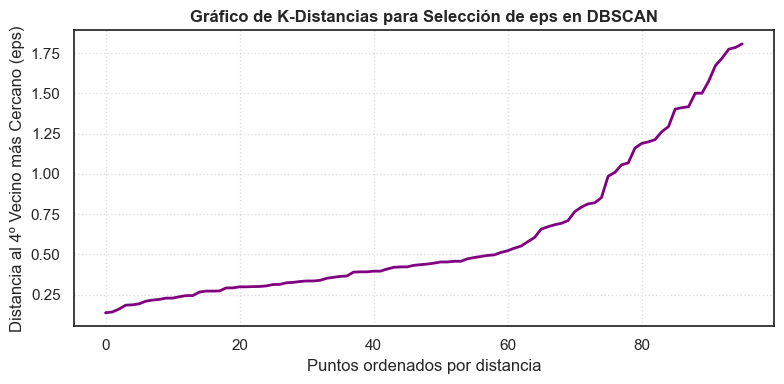

--- RESULTADOS DE DBSCAN ---
Número de clusters detectados (sin ruido): 6
Número de puntos detectados como RUIDO (-1): 36 (37.5%)


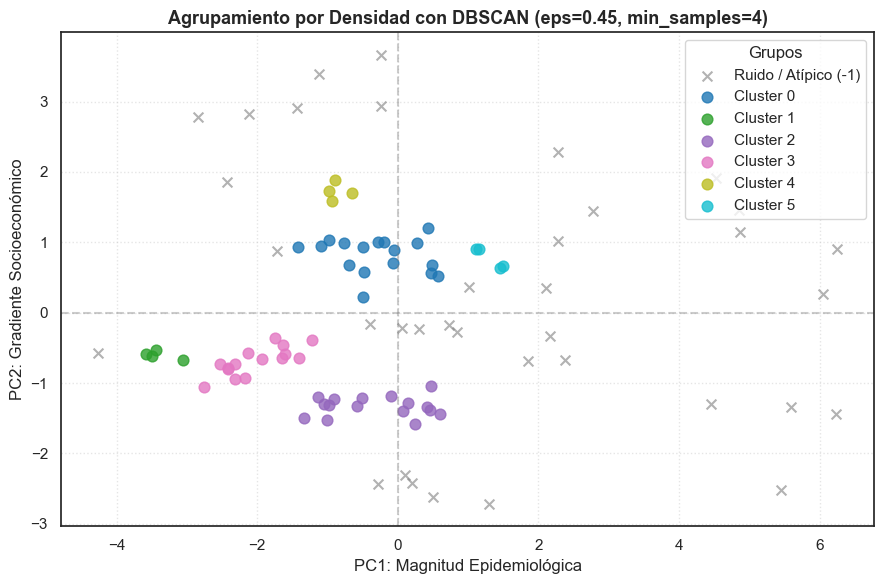


--- TABLA COMPARATIVA DE EVALUACIÓN ---
                          Métrica K-Means (K=5) DBSCAN
                   Nº de Clusters             5      6
         Puntos de Ruido/Outliers             0     36
       Silhouette Score (↑ mejor)        0.4452 0.4529
   Davies-Bouldin Index (↓ mejor)        0.7199 0.5774
Calinski-Harabasz Index (↑ mejor)        110.21  81.46


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors

# Asumimos que X_pca_2d contiene las columnas ['PC1', 'PC2']
# -------------------------------------------------------------------------
# 1. Encontrar el 'eps' óptimo con el gráfico de K-Distancias (min_samples = 4)
# -------------------------------------------------------------------------
min_samples = 4
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca_2d)
distances, indices = neighbors_fit.kneighbors(X_pca_2d)

# Ordenar las distancias al 4to vecino más cercano
distances = np.sort(distances[:, min_samples - 1], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distances, color='purple', linewidth=2)
plt.title(
    'Gráfico de K-Distancias para Selección de eps en DBSCAN',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al {min_samples}º Vecino más Cercano (eps)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('modelo/codoDBSCAN.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 2. Ajuste de DBSCAN con el eps seleccionado
# -------------------------------------------------------------------------
# Ajusta eps según el codo de la gráfica (típicamente entre 0.3 y 0.6)
eps_optimo = 0.45

dbscan = DBSCAN(eps=eps_optimo, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_pca_2d)

df_pca['cluster_dbscan'] = labels_dbscan

# Conteo de puntos por cluster (Recordatorio: -1 indica puntos de Ruido/Outliers)
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print('--- RESULTADOS DE DBSCAN ---')
print(f'Número de clusters detectados (sin ruido): {n_clusters_db}')
print(
    f'Número de puntos detectados como RUIDO (-1): {n_noise} ({n_noise/len(X_pca_2d)*100:.1f}%)'
)

# -------------------------------------------------------------------------
# 3. Graficar los Clusters de DBSCAN en el Plano Cartesiano
# -------------------------------------------------------------------------
plt.figure(figsize=(9, 6))

# Puntos de ruido en gris con cruz
if -1 in labels_dbscan:
    noise_df = df_pca[df_pca['cluster_dbscan'] == -1]
    plt.scatter(
        noise_df['PC1'],
        noise_df['PC2'],
        c='gray',
        marker='x',
        s=50,
        label='Ruido / Atípico (-1)',
        alpha=0.6,
    )

# Puntos en clusters
unique_labels = [l for l in set(labels_dbscan) if l != -1]
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    class_df = df_pca[df_pca['cluster_dbscan'] == k]
    plt.scatter(
        class_df['PC1'],
        class_df['PC2'],
        s=60,
        color=[col],
        label=f'Cluster {k}',
        alpha=0.8,
    )

plt.axhline(0, color='gray', linestyle='--', alpha=0.4)
plt.axvline(0, color='gray', linestyle='--', alpha=0.4)
plt.title(
    f'Agrupamiento por Densidad con DBSCAN (eps={eps_optimo}, min_samples={min_samples})',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('PC1: Magnitud Epidemiológica')
plt.ylabel('PC2: Gradiente Socioeconómico')
plt.legend(title='Grupos', loc='best')
plt.grid(True, linestyle=':', alpha=0.5)
plt.savefig('modelo/agrupamientoDBSCAN.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 4. Tabla Comparativa de Métricas: K-Means vs. DBSCAN
# -------------------------------------------------------------------------
# Para evaluar DBSCAN en Silhouette/Davies-Bouldin, se deben excluir los puntos de ruido
mask_no_noise = labels_dbscan != -1
X_no_noise = X_pca_2d[mask_no_noise]
labels_db_no_noise = labels_dbscan[mask_no_noise]

# Métricas K-Means (K=5)
sil_km = silhouette_score(X_pca_2d, tasas_alcaldias['cluster_k5'])
db_km = davies_bouldin_score(X_pca_2d, tasas_alcaldias['cluster_k5'])
ch_km = calinski_harabasz_score(X_pca_2d, tasas_alcaldias['cluster_k5'])

# Métricas DBSCAN (excluyendo ruido)
if len(set(labels_db_no_noise)) > 1:
    sil_db = silhouette_score(X_no_noise, labels_db_no_noise)
    db_db = davies_bouldin_score(X_no_noise, labels_db_no_noise)
    ch_db = calinski_harabasz_score(X_no_noise, labels_db_no_noise)
else:
    sil_db, db_db, ch_db = np.nan, np.nan, np.nan

df_comparativa = pd.DataFrame(
    {
        'Métrica': [
            'Nº de Clusters',
            'Puntos de Ruido/Outliers',
            'Silhouette Score (↑ mejor)',
            'Davies-Bouldin Index (↓ mejor)',
            'Calinski-Harabasz Index (↑ mejor)',
        ],
        'K-Means (K=5)': [
            5,
            0,
            f'{sil_km:.4f}',
            f'{db_km:.4f}',
            f'{ch_km:.2f}',
        ],
        'DBSCAN': [
            n_clusters_db,
            n_noise,
            f'{sil_db:.4f}' if not np.isnan(sil_db) else 'N/A',
            f'{db_db:.4f}' if not np.isnan(db_db) else 'N/A',
            f'{ch_db:.2f}' if not np.isnan(ch_db) else 'N/A',
        ],
    }
)
# Guardar etiquetas de DBSCAN en el DataFrame principal
tasas_alcaldias['cluster_dbscan'] = labels_dbscan
print('\n--- TABLA COMPARATIVA DE EVALUACIÓN ---')
print(df_comparativa.to_string(index=False))

In [17]:
tasas_alcaldias.columns

Index(['año', 'nom_mun', 'tasa_mortalidad', 'tasa_mortalidad_masc',
       'tasa_mortalidad_fem', 'pobreza_porcentaje', 'tasa_edad_0_14',
       'tasa_edad_15_24', 'tasa_edad_25_59', 'tasa_edad_60mas',
       'tasa_esc_sin_preescolar', 'tasa_esc_primaria', 'tasa_esc_secundaria',
       'tasa_esc_prep_superior', 'cluster_k5', 'cluster_dbscan'],
      dtype='object')

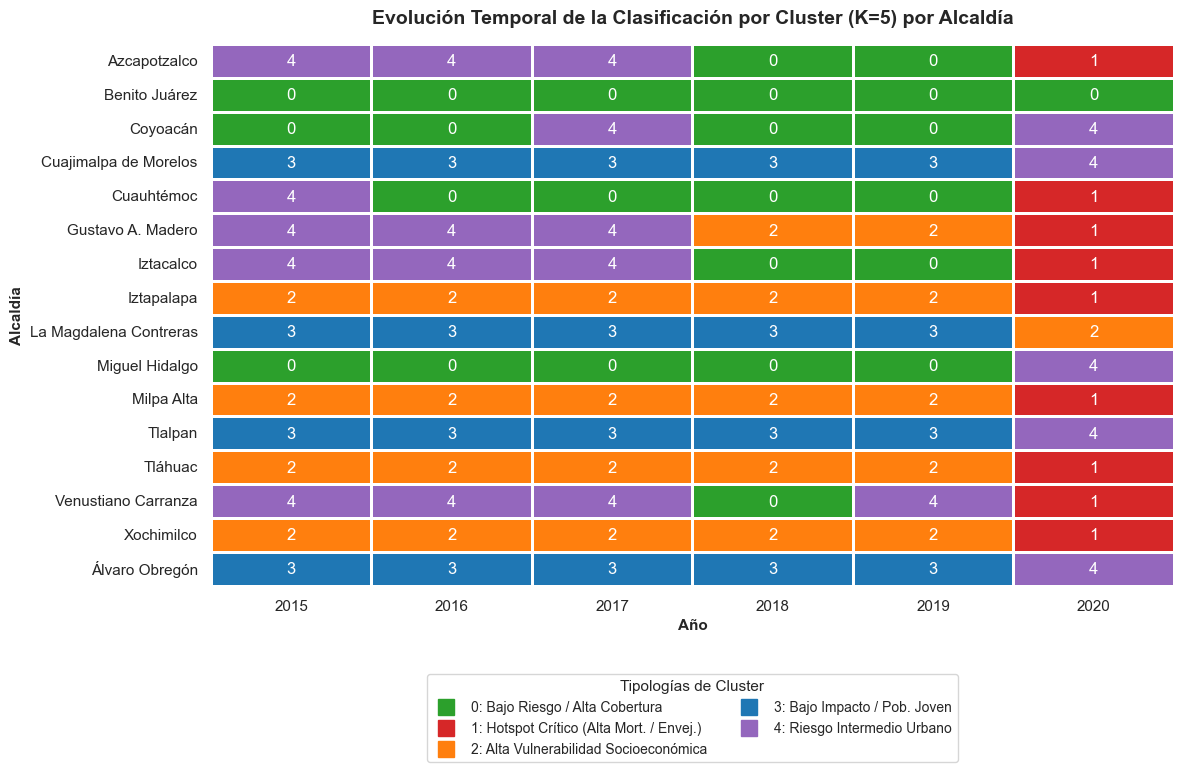

In [18]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#mapa de calor de kmeans
# -------------------------------------------------------------------------
# 1. Crear Matriz Pivote: Alcaldías (Filas) vs Años (Columnas)
# -------------------------------------------------------------------------
# Asumimos que tu DataFrame original 'tasas_alcaldias' tiene las columnas:
# 'alcaldia', 'anio' (o 'fecha') y 'cluster_k5'

pivote_clusters = tasas_alcaldias.pivot(
    index='nom_mun', columns='año', values='cluster_k5'
)

# Ordenar las alcaldías alfabéticamente o por cluster promedio
pivote_clusters = pivote_clusters.sort_index()

# -------------------------------------------------------------------------
# 2. Definir Paleta de Colores Discreta y Categórica
# -------------------------------------------------------------------------
# Nombres personalizados para la leyenda según la caracterización previa
nombres_clusters = {
    0: '0: Bajo Riesgo / Alta Cobertura',
    1: '1: Hotspot Crítico (Alta Mort. / Envej.)',
    2: '2: Alta Vulnerabilidad Socioeconómica',
    3: '3: Bajo Impacto / Pob. Joven',
    4: '4: Riesgo Intermedio Urbano',
}

# Colores sugeridos contrastantes
colores_list = [
    '#2ca02c',
    '#d62728',
    '#ff7f0e',
    '#1f77b4',
    '#9467bd',
]  # Verde, Rojo, Naranja, Azul, Morado
cmap_custom = mcolors.ListedColormap(colores_list)
bounds = [0, 1, 2, 3, 4, 5]
norm = mcolors.BoundaryNorm(bounds, cmap_custom.N)

# -------------------------------------------------------------------------
# 3. Generar el Mapa de Calor
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

# Dibujar heatmap
sns.heatmap(
    pivote_clusters,
    annot=True,  # Mostrar el número de cluster en cada celda
    fmt='d',
    cmap=cmap_custom,
    norm=norm,
    linewidths=1,
    linecolor='white',
    cbar=False,  # Desactivamos la barra predeterminada para poner una leyenda clara
    ax=ax,
)

# Configuración de ejes y títulos
ax.set_title(
    'Evolución Temporal de la Clasificación por Cluster (K=5) por Alcaldía',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Año', fontsize=11, fontweight='bold')
ax.set_ylabel('Alcaldía', fontsize=11, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

# -------------------------------------------------------------------------
# 4. Agregar Leyenda Personalizada
# -------------------------------------------------------------------------
patches = [
    plt.plot(
        [],
        [],
        marker='s',
        ms=12,
        ls='',
        mec=None,
        color=colores_list[i],
        label=nombres_clusters[i],
    )[0]
    for i in range(5)
]

plt.legend(
    handles=patches,
    bbox_to_anchor=(0.5, -0.15),
    loc='upper center',
    ncol=2,
    frameon=True,
    fontsize=10,
    title='Tipologías de Cluster',
    title_fontsize=11,
)
plt.savefig('modelo/evolucionKMEANS.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

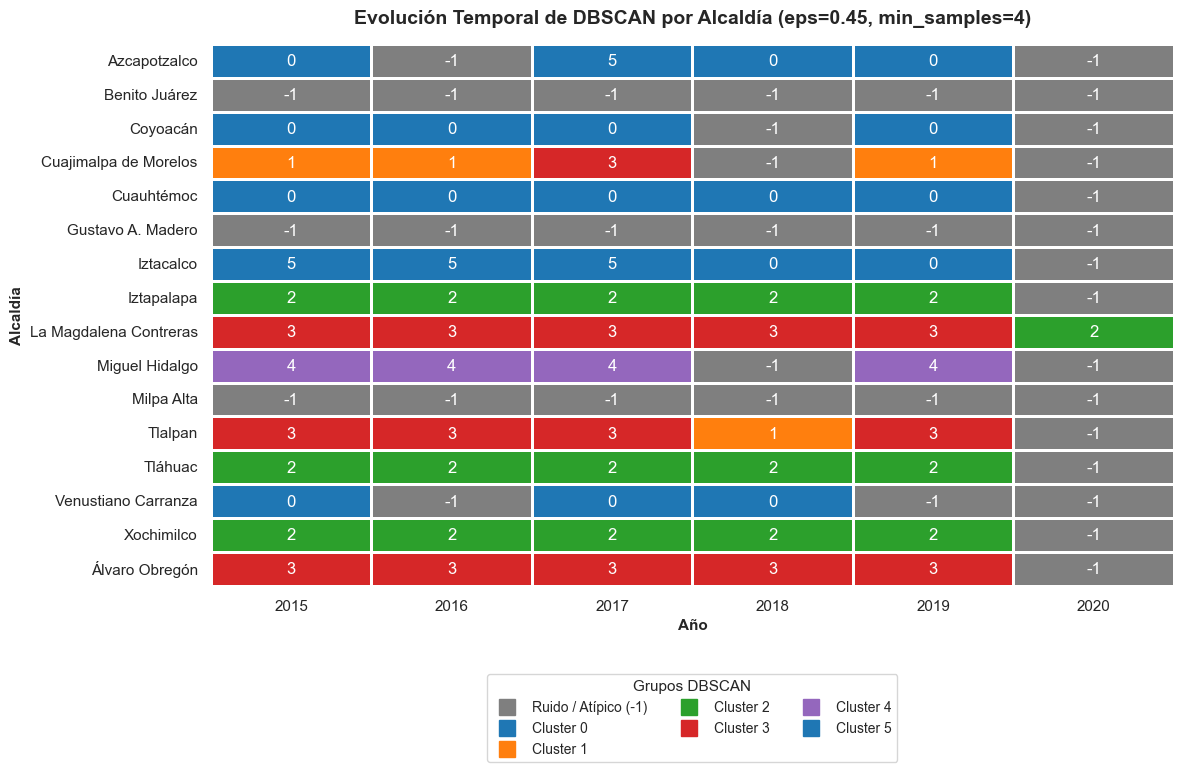

In [19]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# -------------------------------------------------------------------------
# 1. Crear Matriz Pivote usando 'cluster_dbscan'
# -------------------------------------------------------------------------
pivote_dbscan = tasas_alcaldias.pivot(
    index='nom_mun', columns='año', values='cluster_dbscan'
).sort_index()

# -------------------------------------------------------------------------
# 2. Configurar la paleta de colores (Manejando el valor -1)
# -------------------------------------------------------------------------
# Identificar qué clusters existen en los datos (ej: -1, 0, 1)
etiquetas_unicas = sorted(tasas_alcaldias['cluster_dbscan'].unique())

# Diccionario de nombres para la leyenda
nombres_dbscan = {-1: 'Ruido / Atípico (-1)'}
for lbl in etiquetas_unicas:
    if lbl != -1:
        nombres_dbscan[lbl] = f'Cluster {lbl}'

# Asignar gris para -1 y colores distintos para cada cluster (0, 1, ...)
colores_dict = {-1: '#7f7f7f'}  # Gris para el ruido
colores_clusters = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

idx_col = 0
for lbl in etiquetas_unicas:
    if lbl != -1:
        colores_dict[lbl] = colores_clusters[idx_col % len(colores_clusters)]
        idx_col += 1

lista_colores = [colores_dict[lbl] for lbl in etiquetas_unicas]
cmap_dbscan = mcolors.ListedColormap(lista_colores)

# Crear límites de intervalos para la escala
bounds = np.append(etiquetas_unicas, max(etiquetas_unicas) + 1) - 0.5
norm_dbscan = mcolors.BoundaryNorm(bounds, cmap_dbscan.N)

# -------------------------------------------------------------------------
# 3. Generar el Mapa de Calor para DBSCAN
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    pivote_dbscan,
    annot=True,
    fmt='d',
    cmap=cmap_dbscan,
    norm=norm_dbscan,
    linewidths=1,
    linecolor='white',
    cbar=False,
    ax=ax,
)

ax.set_title(
    f'Evolución Temporal de DBSCAN por Alcaldía (eps={eps_optimo}, min_samples={min_samples})',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Año', fontsize=11, fontweight='bold')
ax.set_ylabel('Alcaldía', fontsize=11, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

# -------------------------------------------------------------------------
# 4. Leyenda de DBSCAN
# -------------------------------------------------------------------------
patches = [
    plt.plot(
        [],
        [],
        marker='s',
        ms=12,
        ls='',
        color=colores_dict[lbl],
        label=nombres_dbscan[lbl],
    )[0]
    for lbl in etiquetas_unicas
]

plt.legend(
    handles=patches,
    bbox_to_anchor=(0.5, -0.15),
    loc='upper center',
    ncol=3,
    frameon=True,
    fontsize=10,
    title='Grupos DBSCAN',
    title_fontsize=11,
)
plt.savefig('modelo/evolucionDBSCAN.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

=== MATRIZ DE FRECUENCIAS DE TRANSICIÓN (CONTEOS) ===
Estado en t+1 (Año siguiente)   0  1   2   3  4
Estado en t (Año actual)                       
0                              16  3   0   0  4
1                               0  0   0   0  0
2                               0  5  17   0  0
3                               0  0   1  16  3
4                               5  1   1   0  8

=== MATRIZ DE PROBABILIDADES DE TRANSICIÓN P(t+1 | t) ===
Estado en t+1 (Año siguiente)       0       1       2    3       4
Estado en t (Año actual)                                          
0                              0.6957  0.1304  0.0000  0.0  0.1739
1                              0.0000  0.0000  0.0000  0.0  0.0000
2                              0.0000  0.2273  0.7727  0.0  0.0000
3                              0.0000  0.0000  0.0500  0.8  0.1500
4                              0.3333  0.0667  0.0667  0.0  0.5333


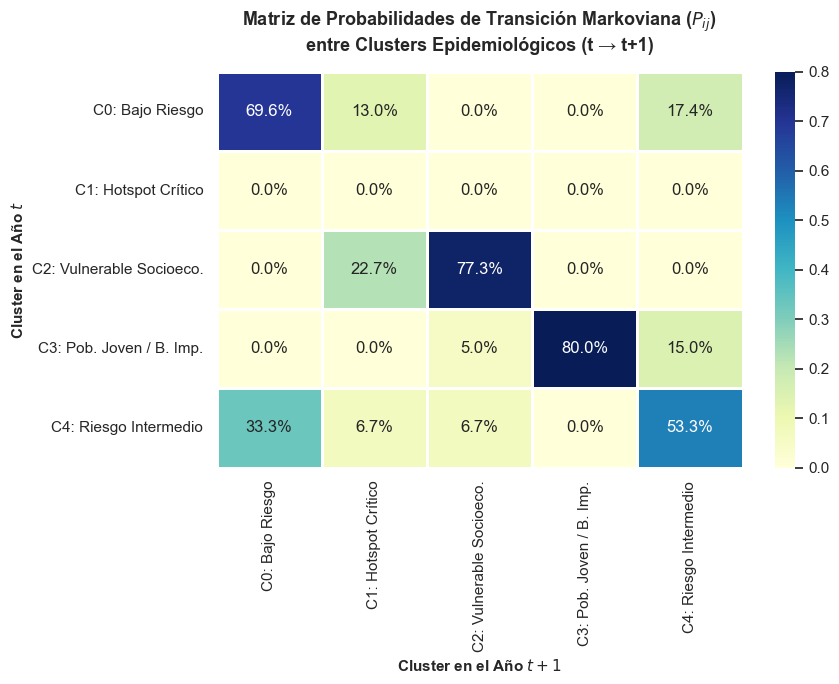

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# -------------------------------------------------------------------------
# 1. Preparar los datos longitudinales (t vs t+1)
# -------------------------------------------------------------------------
# Asegurar que los datos están ordenados por alcaldía y por año
df_sorted = tasas_alcaldias.sort_values(by=['nom_mun', 'año']).copy()

# Crear la columna desplazada (lagged) para obtener el cluster del año siguiente (t+1)
df_sorted['cluster_t'] = df_sorted['cluster_k5']
df_sorted['cluster_t_plus_1'] = df_sorted.groupby('nom_mun')[
    'cluster_k5'
].shift(-1)

# Eliminar las filas con NaN en t+1 (corresponden al último año observado por alcaldía)
df_transitions = df_sorted.dropna(subset=['cluster_t_plus_1']).copy()
df_transitions['cluster_t_plus_1'] = df_transitions[
    'cluster_t_plus_1'
].astype(int)

# -------------------------------------------------------------------------
# 2. Construir la Matriz de Frecuencias Observadas (Conteo de Cambios)
# -------------------------------------------------------------------------
matriz_frecuencias = pd.crosstab(
    df_transitions['cluster_t'],
    df_transitions['cluster_t_plus_1'],
    rownames=['Estado en t (Año actual)'],
    colnames=['Estado en t+1 (Año siguiente)'],
    dropna=False,
).reindex(index=range(5), columns=range(5), fill_value=0)

print('=== MATRIZ DE FRECUENCIAS DE TRANSICIÓN (CONTEOS) ===')
print(matriz_frecuencias)

# -------------------------------------------------------------------------
# 3. Calcular la Matriz de Probabilidades de Transición (Cadenas de Markov)
# -------------------------------------------------------------------------
# Normalizar por filas (cada fila suma 1.0 / 100%)
matriz_probabilidades = matriz_frecuencias.div(
    matriz_frecuencias.sum(axis=1), axis=0
).fillna(0)

print('\n=== MATRIZ DE PROBABILIDADES DE TRANSICIÓN P(t+1 | t) ===')
print(matriz_probabilidades.round(4))

# -------------------------------------------------------------------------
# 4. Visualizar la Matriz de Probabilidades como Heatmap
# -------------------------------------------------------------------------
etiquetas_clusters = [
    'C0: Bajo Riesgo',
    'C1: Hotspot Crítico',
    'C2: Vulnerable Socioeco.',
    'C3: Pob. Joven / B. Imp.',
    'C4: Riesgo Intermedio',
]

plt.figure(figsize=(9, 7))
sns.heatmap(
    matriz_probabilidades,
    annot=True,
    fmt='.1%',  # Formato en porcentaje (ej. 85.5%)
    cmap='YlGnBu',
    cbar=True,
    xticklabels=etiquetas_clusters,
    yticklabels=etiquetas_clusters,
    linewidths=1,
    linecolor='white',
)

plt.title(
    'Matriz de Probabilidades de Transición Markoviana ($P_{ij}$)\nentre Clusters'
    ' Epidemiológicos (t → t+1)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Cluster en el Año $t+1$', fontsize=11, fontweight='bold')
plt.ylabel('Cluster en el Año $t$', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## OPTICS